In [ ]:
%pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("jaimetrickz/galaxy-zoo-2-images")

print("Path to dataset files:", path)

100%|██████████| 3.06G/3.06G [00:33<00:00, 97.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jaimetrickz/galaxy-zoo-2-images/versions/1


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import time
import h5py
from sklearn.model_selection import train_test_split

In [ ]:
DATASET_PATH = '/root/.cache/kagglehub/datasets/jaimetrickz/galaxy-zoo-2-images/versions/1'

image_paths = glob.glob(os.path.join(DATASET_PATH, '**', '*.jpg'), recursive=True)
print(f"Se encontraron {len(image_paths)} imágenes")

Se encontraron 243434 imágenes


In [ ]:
BATCH_SIZE = 64         # Tamano de la muestra
IMG_SIZE   = (64, 64)   # Tamano de las imagenes (64 x 64) pixeles

dataset = tf.data.Dataset.from_tensor_slices(image_paths)  # Crear dataset



def load_and_preprocess(path):
    img_raw = tf.io.read_file(path)                           # Lee los bytes del archivo
    img     = tf.image.decode_jpeg(img_raw, channels=3)       # Decodifica JPEG a tensor (RGB)
    img     = tf.image.resize(img, IMG_SIZE)                  # Redimensionar la imagen
    img     = tf.cast(img, tf.float32)                        # Convertir a float32
    img     = (img - 127.5) / 127.5                           # Normalizar de [0,255] a [–1,1]
    return img

dataset = (
    dataset
    .shuffle(buffer_size=len(image_paths))                    # Seleccionar aleatoriamente
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                                                              # Paralelizar
    .batch(BATCH_SIZE)                                        # Agrupar en lotes
    .prefetch(tf.data.AUTOTUNE)
)

print(dataset)


<_PrefetchDataset element_spec=TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None)>


In [ ]:
def make_generator_model(latent_dim=100):

    model = tf.keras.Sequential([

        layers.Dense(8*8*512, use_bias=False, input_shape=(latent_dim,)),  # Capa densa 8*8*512 neuronas, sin sesgo
        layers.BatchNormalization(),                                       # Normalizacion
        layers.LeakyReLU(),                                                # Evita neuronas muertas
        layers.Reshape((8, 8, 512)),

        layers.Conv2DTranspose(256, (5, 5), strides=(2, 2),                # 8×8 → 16×16, manteniendo las dimensiones
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2),                #16×16 →32×32
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2),                 #32×32 →64×64
                               padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(3, (5, 5), strides=(1, 1),                  #Salida
                               padding='same', use_bias=False,
                               activation='tanh'),
    ])
    return model

def make_discriminator_model():

    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',         #64x64 →32×32
                      input_shape=[64, 64, 3]),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),                                               #Elimina aleatoriamente 30% de neuronas durante entrenamiento(evita el sobreajuste)

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),        #32×32 →16×16
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'),        #16×16 →8×8
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),                                                  # Aplanar
        layers.Dense(1),
    ])
    return model

latent_dim = 100
generator     = make_generator_model(latent_dim)
discriminator = make_discriminator_model()

generator.summary()
discriminator.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32768)          │     3,276,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 16, 16, 256)    │     3,276,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 32, 32, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 64, 64, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 64, 3)      │         4,800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,715,264 (29.43 MB)

 Trainable params: 7,648,832 (29.18 MB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,633 (3.99 MB)

 Trainable params: 1,045,633 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)   #Funcion de perdida

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):

    return cross_entropy(tf.ones_like(fake_output), fake_output)


In [ ]:
#Optimizadores
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
EPOCHS     = 10                # Epocas de entrenamiento
LATENT_DIM = 100               # Dimensión del espacio latente
BATCH_SIZE = 64                # Tamaño del lote

seed = tf.random.normal([16, LATENT_DIM])   # Semilla con distribucion normal, para generar 16 imagenes

@tf.function                                # Compilacion just in time
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])   # Generacion de ruido

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:    # Entrenamiento
        generated_images = generator(noise, training=True)                 # Crear imagenes

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)
                                                                           # Pasa por el discriminador las imagenes reales y sinteticas
          gen_loss  = generator_loss(fake_output)
          disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator     = gen_tape.gradient(gen_loss,  generator.trainable_variables)        # Calcula los gradientes
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator,     generator.trainable_variables))     # se actualizan los pesos
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


def train(dataset, epochs):
    for epoch in range(epochs):
        print(f"Iniciando época {epoch+1}/{epochs}")

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)

        generated = generator(seed, training=False)
        print(f"  Pérdida G: {g_loss:.4f},  Pérdida D: {d_loss:.4f}")
train(dataset, EPOCHS)


Iniciando época 1/7
  Pérdida G: 1.3546,  Pérdida D: 0.7816
Iniciando época 2/7
  Pérdida G: 1.2160,  Pérdida D: 0.7798
Iniciando época 3/7
  Pérdida G: 1.1483,  Pérdida D: 1.0584
Iniciando época 4/7
  Pérdida G: 1.0901,  Pérdida D: 0.9365
Iniciando época 5/7
  Pérdida G: 1.5769,  Pérdida D: 1.0586
Iniciando época 6/7
  Pérdida G: 0.7466,  Pérdida D: 1.3424
Iniciando época 7/7
  Pérdida G: 0.8028,  Pérdida D: 1.4219


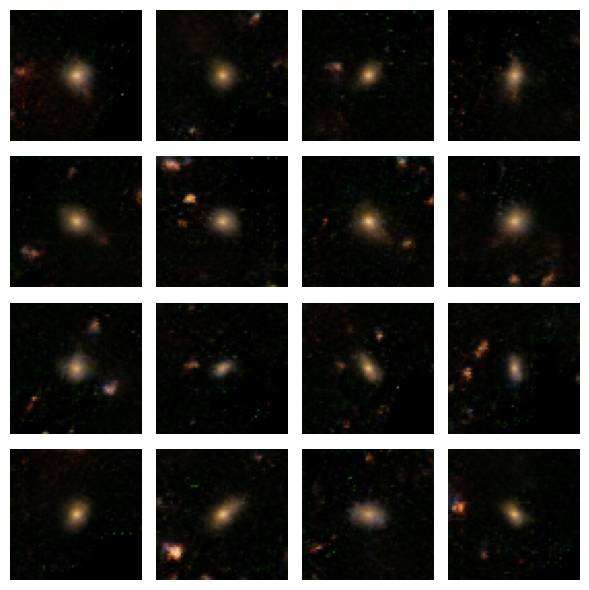

In [ ]:

train(dataset, epochs=7)                  # Entrenamos por 7 epocas

def show_generated_images(model, seed):
    gen = model(seed, training=False)
    gen = (gen + 1.0) / 2.0              # Reescalar

    fig, axes = plt.subplots(4, 4, figsize=(6,6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(gen[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_generated_images(generator, seed)
